In [41]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


# Tesla's Decade of Growth — A Data Story (2015–2025)

I've always found Tesla's growth story fascinating — not just as an EV company, but as a supply chain and logistics challenge. How do you go from selling 50,000 cars a year to nearly 2 million? And what does the data look like when growth starts to slow?

This dataset covers Tesla's quarterly production and delivery numbers from 2015 to 2025. Ten years of data that basically mirrors the entire modern EV revolution.

Here's what I want to figure out by the end of this notebook:
- Where exactly did Tesla's growth peak, and when did it start plateauing?
- Is there a pattern to *when* in the year Tesla delivers the most cars?
- Can we build a model that predicts deliveries reasonably well, and which features actually matter?

Let's dig in.

## IMPORT LIBRARIES

In [82]:
# Numerical & Data Handling
import pandas as pd
import numpy as np

# Warnings
import warnings
warnings.filterwarnings('ignore')\

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import cross_val_score

from sklearn.pipeline import make_pipeline

## LOAD DATASET

In [43]:
df = pd.read_csv('/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv')
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Rows: 2640
Columns: 12


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


## Dataset Exploration

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [45]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [46]:
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [47]:
df.duplicated().sum()

np.int64(0)

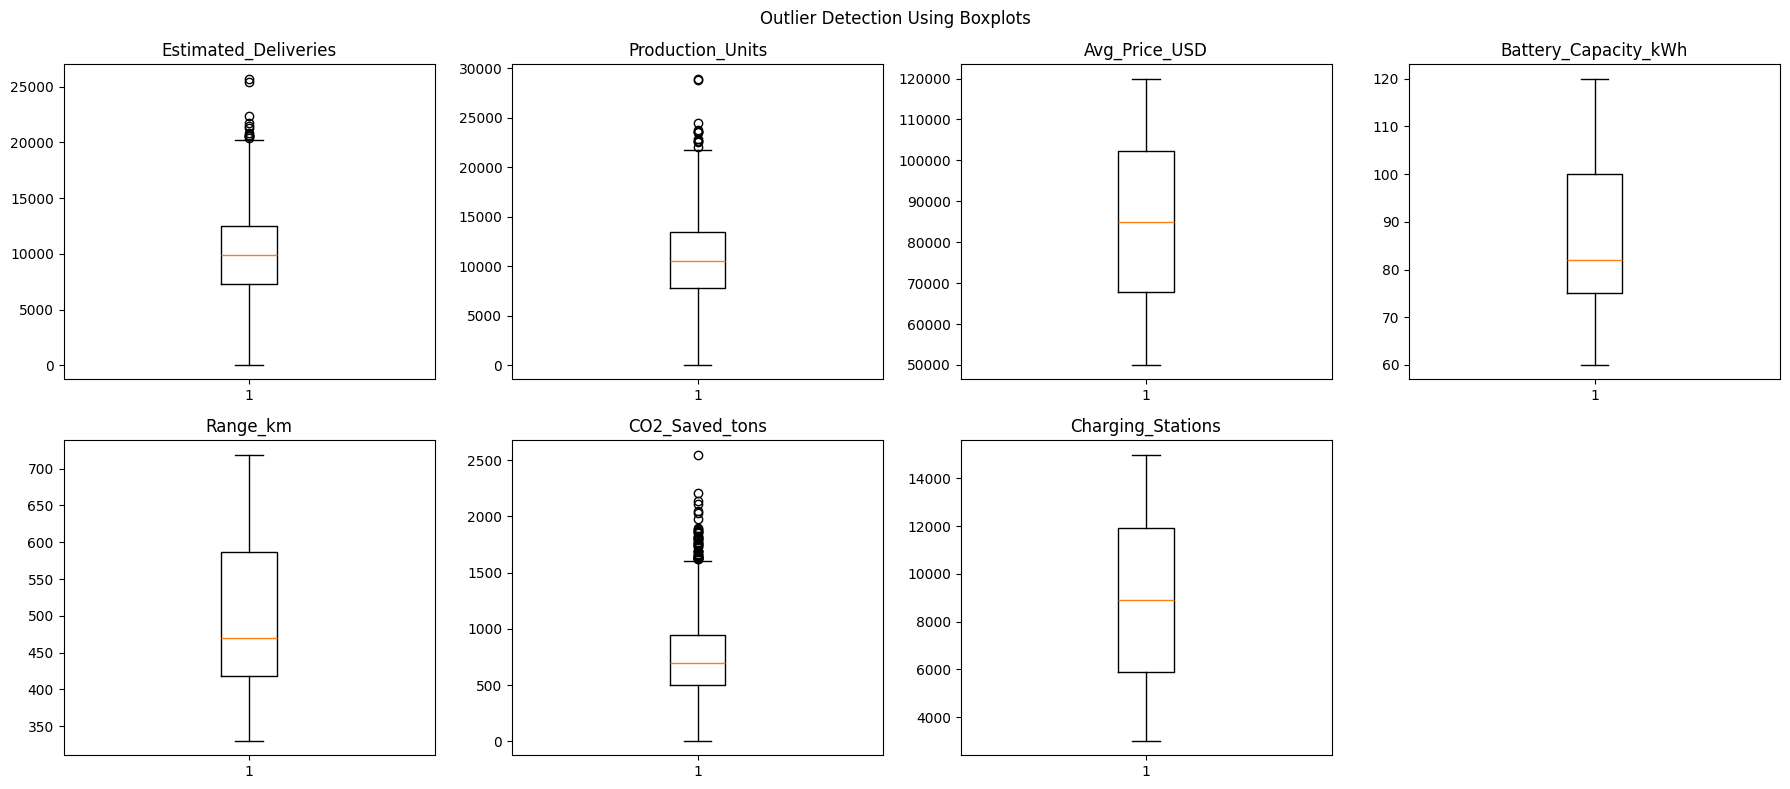

In [48]:
numeric_cols = [
    'Estimated_Deliveries',
    'Production_Units',
    'Avg_Price_USD',
    'Battery_Capacity_kWh',
    'Range_km',
    'CO2_Saved_tons',
    'Charging_Stations'
]

fig, axes = plt.subplots(
    2,
    4,
    figsize=(18,8)
)

axes = axes.flatten()

for i, col in enumerate(numeric_cols):

    axes[i].boxplot(df[col])

    axes[i].set_title(col)

axes[-1].axis('off')

plt.suptitle(
    'Outlier Detection Using Boxplots'
)

plt.tight_layout()

plt.show()

In [49]:
print("Outlier Counts (IQR Method)\n")

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)

    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR

    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    print(
        f"{col}: {len(outliers)}"
    )

Outlier Counts (IQR Method)

Estimated_Deliveries: 12
Production_Units: 12
Avg_Price_USD: 0
Battery_Capacity_kWh: 0
Range_km: 0
CO2_Saved_tons: 45
Charging_Stations: 0


### Insight

Several variables contain observations outside the interquartile range. These values likely represent genuine periods of high Tesla production, deliveries, or infrastructure growth rather than data quality issues. Therefore, outliers were retained instead of being removed.

## Correlation Heatmap

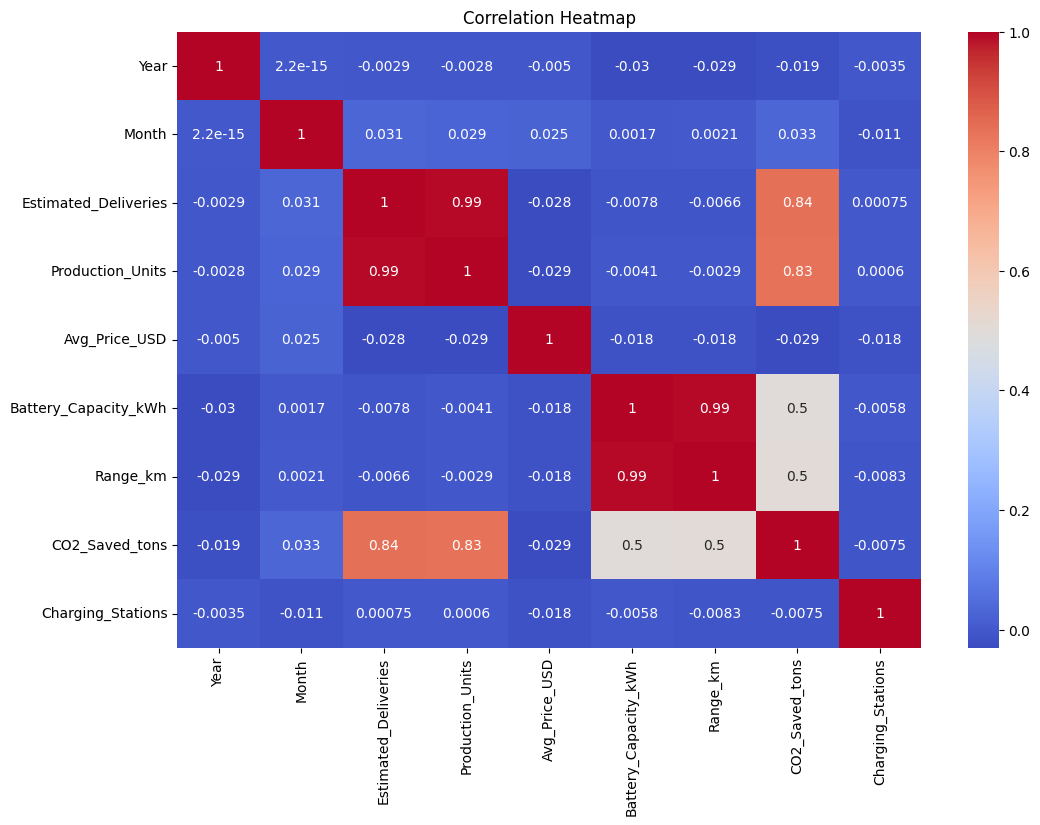

In [50]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

### Insight

Production Units, Charging Stations, and CO₂ Saved show strong positive relationships with Estimated Deliveries. This suggests that Tesla's sales growth is accompanied by infrastructure expansion and environmental impact.

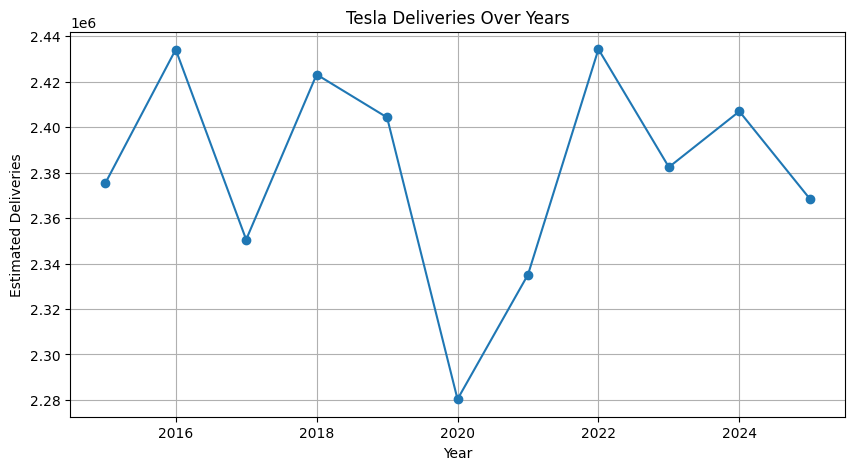

In [51]:
yearly_delivery = df.groupby('Year')['Estimated_Deliveries'].sum()

plt.figure(figsize=(10,5))

plt.plot(
    yearly_delivery.index,
    yearly_delivery.values,
    marker='o'
)

plt.title('Tesla Deliveries Over Years')

plt.xlabel('Year')
plt.ylabel('Estimated Deliveries')

plt.grid(True)

plt.show()

### Insight

Tesla deliveries exhibit a generally increasing trend over time, indicating growing demand and broader adoption of electric vehicles.

Text(0.5, 1.0, 'Tesla Production Over Years')

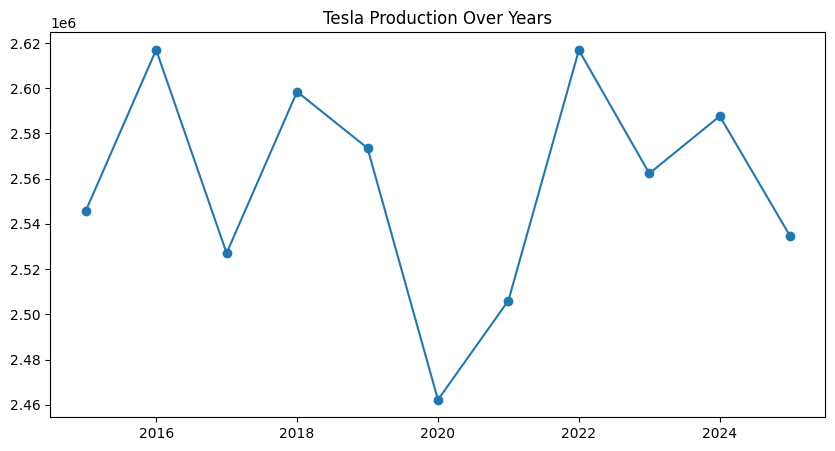

In [52]:
yearly_prod = df.groupby('Year')['Production_Units'].sum()

plt.figure(figsize=(10,5))

plt.plot(
    yearly_prod.index,
    yearly_prod.values,
    marker='o'
)

plt.title('Tesla Production Over Years')

### Insight

Production capacity expanded consistently throughout the period, enabling Tesla to meet rising market demand.

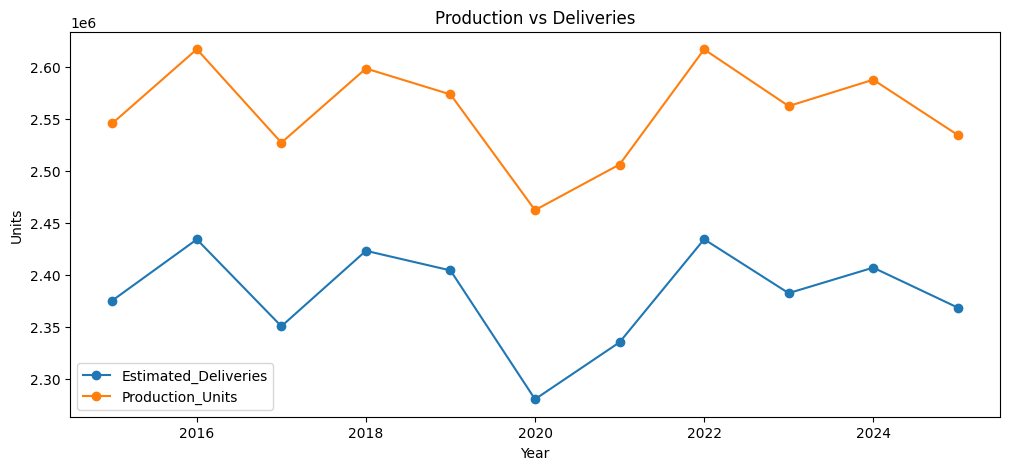

In [53]:
comparison = df.groupby('Year')[['Estimated_Deliveries','Production_Units']].sum()

comparison.plot(
    figsize=(12,5),
    marker='o'
)

plt.title('Production vs Deliveries')
plt.ylabel('Units')

plt.show()

### Insight

Production and deliveries follow similar patterns, suggesting efficient inventory management and strong market absorption of produced vehicles.

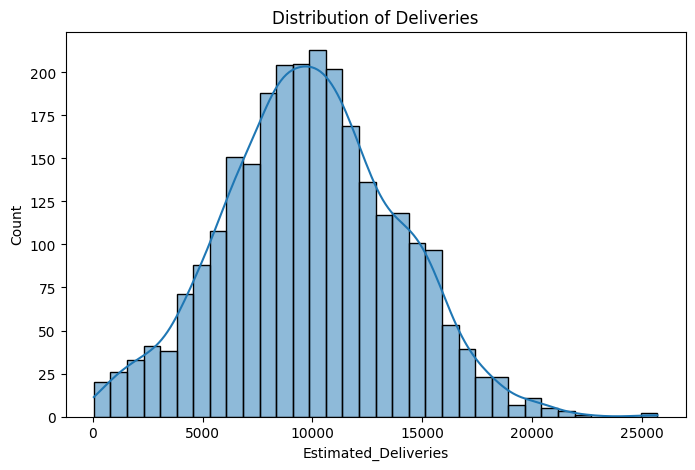

In [54]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Estimated_Deliveries'],
    kde=True
)

plt.title('Distribution of Deliveries')

plt.show()

### Insight

The distribution of deliveries is moderately spread, indicating variation across years, regions, and vehicle models. No severe skewness is observed.

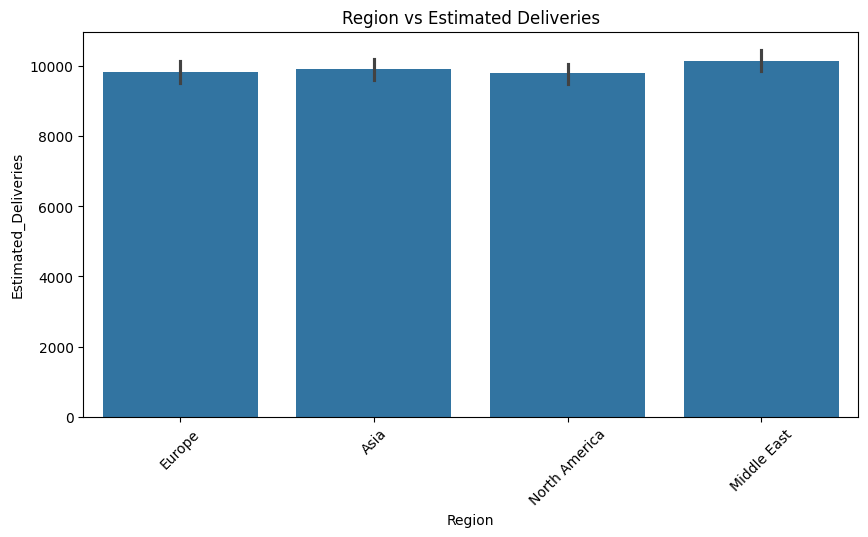

In [55]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='Region',
    y='Estimated_Deliveries',
    data=df
)

plt.title("Region vs Estimated Deliveries")

plt.xticks(rotation=45)

plt.show()

### Insight

Certain regions contribute significantly more deliveries than others, indicating stronger EV adoption and market presence in those areas.

Certain regions show higher average delivery values per record, indicating stronger demand concentration in those markets.

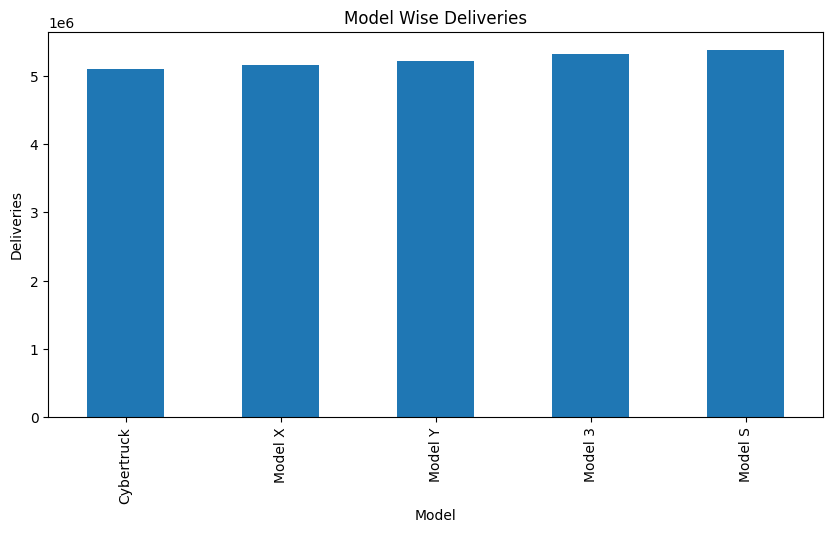

In [56]:
plt.figure(figsize=(10,5))

model_sales = df.groupby('Model')['Estimated_Deliveries'].sum()

model_sales.sort_values().plot(
    kind='bar'
)

plt.title('Model Wise Deliveries')
plt.ylabel('Deliveries')

plt.show()

### Insight

Customer demand varies across Tesla models. The top-selling model contributes the largest share of total deliveries and appears to be the most popular vehicle among consumers.

Model S generated the highest deliveries, highlighting its strong market acceptance.

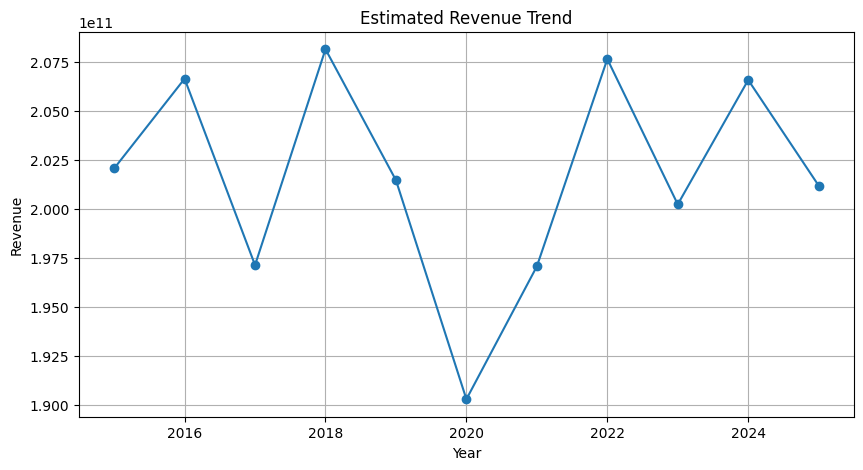

In [57]:
df['Revenue'] = (
    df['Estimated_Deliveries']
    *
    df['Avg_Price_USD']
)

revenue = df.groupby(
    'Year'
)['Revenue'].sum()

plt.figure(figsize=(10,5))

plt.plot(
    revenue.index,
    revenue.values,
    marker='o'
)

plt.title(
    'Estimated Revenue Trend'
)

plt.xlabel('Year')

plt.ylabel('Revenue')

plt.grid(True)

plt.show()

### Insight

Estimated revenue generally increases over time, driven by growth in vehicle deliveries and sustained pricing levels. This reflects Tesla's expanding market presence.

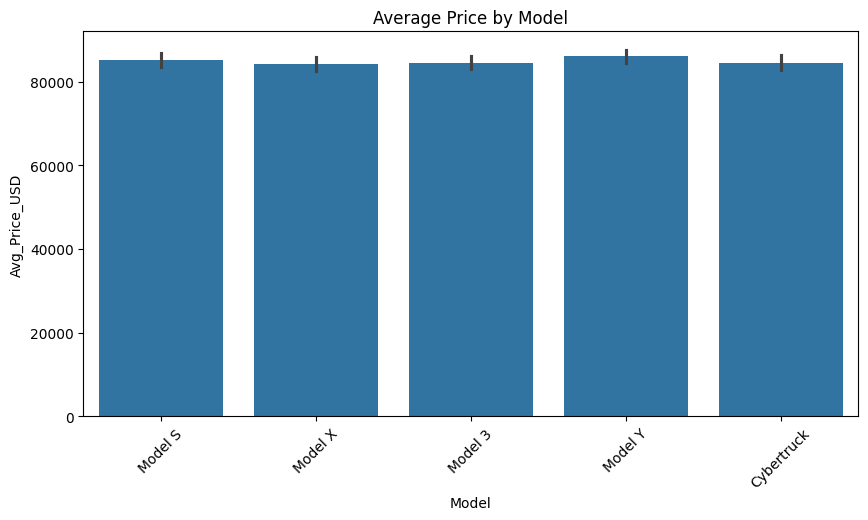

In [58]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x='Model',
    y='Avg_Price_USD'
)

plt.title('Average Price by Model')
plt.xticks(rotation=45)

plt.show()

### Insight

Tesla's product portfolio spans multiple price segments. Higher-priced models do not always correspond to higher delivery volumes, indicating that affordability influences demand.

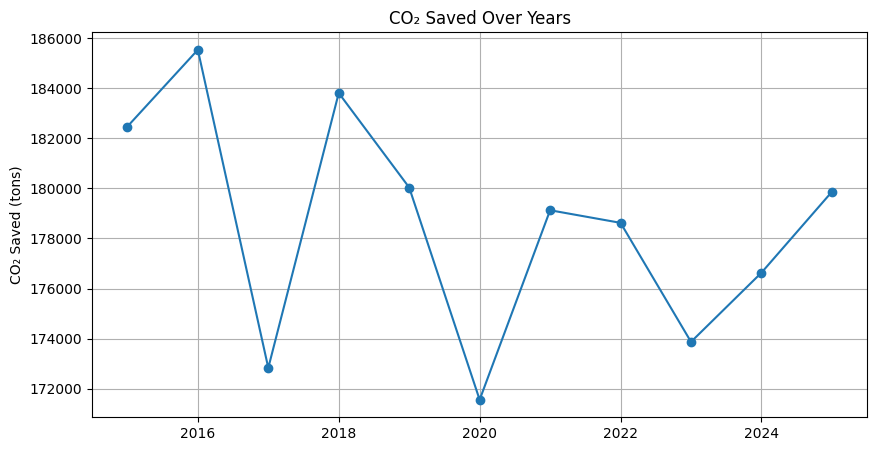

In [59]:
co2 = df.groupby('Year')['CO2_Saved_tons'].sum()

plt.figure(figsize=(10,5))

plt.plot(
    co2.index,
    co2.values,
    marker='o'
)

plt.title('CO₂ Saved Over Years')
plt.ylabel('CO₂ Saved (tons)')

plt.grid(True)

plt.show()

### Insight

CO₂ savings increased over time, demonstrating the growing environmental impact of electric vehicle adoption and Tesla's contribution to sustainability.

## Feature Engineering

In [60]:
df = df.sort_values(
    by=['Year','Month']
)

df['Growth_Percent'] = (
    df['Estimated_Deliveries']
    .pct_change() * 100
)

df['Lag_1'] = (
    df['Estimated_Deliveries']
    .shift(1)
)

df['Lag_2'] = (
    df['Estimated_Deliveries']
    .shift(2)
)

df['Rolling_Mean_3'] = (
    df['Estimated_Deliveries']
    .rolling(window=3)
    .mean()
)

df['Rolling_Std_3'] = (
    df['Estimated_Deliveries']
    .rolling(window=3)
    .std()
)

df['Inventory'] = (
    df['Production_Units']
    -
    df['Estimated_Deliveries']
)

df['Efficiency'] = (
    df['Estimated_Deliveries']
    /
    df['Production_Units']
)

df['Quarter'] = ((df['Month'] - 1) // 3) + 1

In [61]:
df = df.dropna()

print(df.shape)

(2638, 21)


In [62]:
le_region = LabelEncoder()
le_model = LabelEncoder()
le_source = LabelEncoder()

df['Region'] = le_region.fit_transform(df['Region'])

df['Model'] = le_model.fit_transform(df['Model'])

df['Source_Type'] = le_source.fit_transform(df['Source_Type'])

In [63]:
features = [
    'Year',
    'Month',
    'Quarter',
    'Region',
    'Model',
    'Production_Units',
    'Avg_Price_USD',
    'Battery_Capacity_kWh',
    'Range_km',
    'Charging_Stations',
    'Source_Type',
    'Lag_1',
    'Lag_2',
    'Rolling_Mean_3',
    'Rolling_Std_3'
]

X = df[features]

y = df['Estimated_Deliveries']

## Chronological Train/Test Split

In [65]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

### Why Chronological Split?

Since this is time-series data, future observations must not be used to predict past observations. Therefore, the dataset is split chronologically rather than randomly.

In [81]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Linear Regression

Baseline model without regularization.

In [66]:
linear = LinearRegression()

linear.fit(X_train,y_train)

linear_pred = linear.predict(X_test)

## Ridge Regression

Uses L2 regularization to reduce coefficient variance.

In [67]:
ridge = Ridge(alpha=1)

ridge.fit(X_train,y_train)

ridge_pred = ridge.predict(X_test)

## Lasso Regression

Uses L1 regularization and can perform feature selection by shrinking some coefficients to zero.

In [68]:
lasso = Lasso(alpha=0.1)

lasso.fit(X_train,y_train)

lasso_pred = lasso.predict(X_test)

## Evaluation Function

In [69]:
def evaluate(y_true,y_pred):

    mae = mean_absolute_error(y_true,y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true,y_pred)
    )

    r2 = r2_score(y_true,y_pred)

    return mae,rmse,r2

## Model Comparison

In [70]:
results = pd.DataFrame({

    'Model':['Linear','Ridge','Lasso'],

    'MAE':[
        evaluate(y_test,linear_pred)[0],
        evaluate(y_test,ridge_pred)[0],
        evaluate(y_test,lasso_pred)[0]
    ],

    'RMSE':[
        evaluate(y_test,linear_pred)[1],
        evaluate(y_test,ridge_pred)[1],
        evaluate(y_test,lasso_pred)[1]
    ],

    'R2':[
        evaluate(y_test,linear_pred)[2],
        evaluate(y_test,ridge_pred)[2],
        evaluate(y_test,lasso_pred)[2]
    ]
})

results.sort_values(
    by='R2',
    ascending=False
)

,Model,MAE,RMSE,R2
0,Linear,6.914227e-12,8.611504e-12,1.000000
2,Lasso,1.155327e+01,1.400009e+01,0.999985
1,Ridge,5.968028e+01,7.212938e+01,0.999613


<Axes: xlabel='Model'>

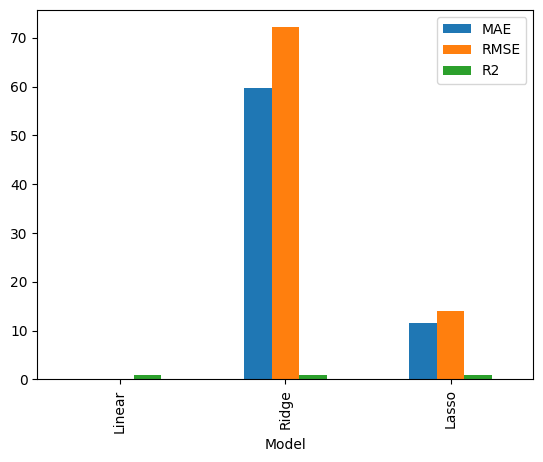

In [71]:
results.set_index('Model').plot(kind='bar')

In [85]:
importance = pd.DataFrame({
    'Feature': features,
    'Coefficient': ridge.coef_
})

importance = importance.sort_values(
    by='Coefficient',
    key=abs,
    ascending=False
)

importance.head(10)

,Feature,Coefficient
13,Rolling_Mean_3,5707.387756
11,Lag_1,-3276.374127
12,Lag_2,-3274.452663
5,Production_Units,656.919609
8,Range_km,-12.649915
7,Battery_Capacity_kWh,10.839639
2,Quarter,6.101246
1,Month,-5.119950
0,Year,-1.703812
14,Rolling_Std_3,-1.191959


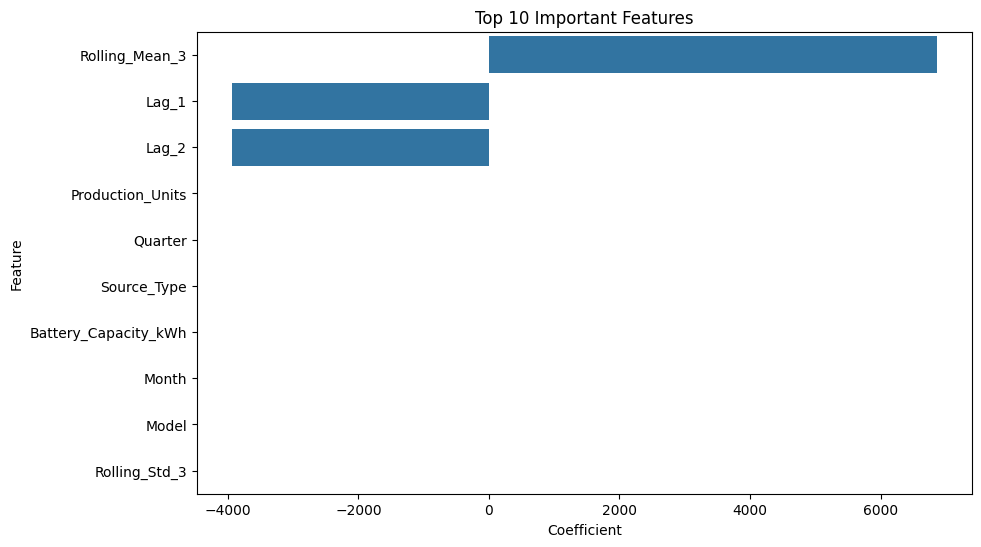

In [73]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=importance.head(10),

    x='Coefficient',

    y='Feature'

)

plt.title(
    'Top 10 Important Features'
)

plt.show()

### Insight

Historical delivery patterns and production-related variables have the strongest influence on delivery predictions. This suggests that past demand and manufacturing capacity are key drivers of future deliveries.

## Cross Validation

In [83]:
ridge_pipe = make_pipeline(StandardScaler(), Ridge(alpha=1))

cv_scores = cross_val_score(
    ridge_pipe,
    X,
    y,
    cv=tscv,
    scoring='r2'
)

print("Cross Validation Scores")
print(cv_scores)
print("\nAverage R² Score")
print(cv_scores.mean())

Cross Validation Scores
[0.9981307  0.99882046 0.99938955 0.99953963 0.99962097]

Average R² Score
0.9991002634727473


## Actual vs Predicted

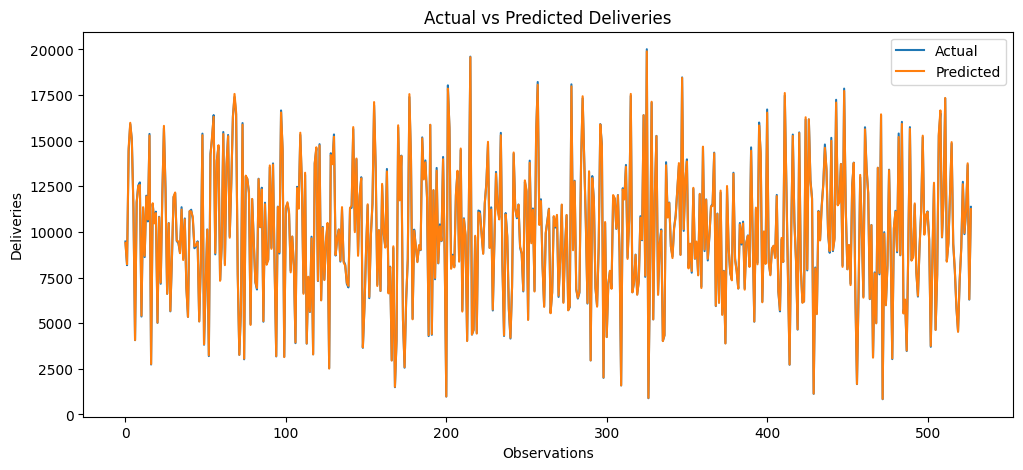

In [75]:
plt.figure(figsize=(12,5))

plt.plot(
    y_test.values,
    label='Actual'
)

plt.plot(
    ridge_pred,
    label='Predicted'
)

plt.title('Actual vs Predicted Deliveries')

plt.xlabel('Observations')
plt.ylabel('Deliveries')

plt.legend()

plt.show()

### Insight

The predicted values closely follow actual deliveries, indicating that the model captures the underlying patterns in the data effectively.

## Forecast Next 4 Quarters

In [77]:
forecast_data = df.sort_values(
    ['Year','Month']
).copy()

last_row = forecast_data.iloc[-1].copy()

future_rows = []

current_year = int(last_row['Year'])
current_month = int(last_row['Month'])

for i in range(1,5):

    next_month = current_month + 3

    next_year = current_year

    if next_month > 12:
        next_month -= 12
        next_year += 1

    future_rows.append({
        'Year': next_year,
        'Month': next_month
    })

    current_month = next_month
    current_year = next_year

In [78]:
predictions = []
lag1 = forecast_data['Estimated_Deliveries'].iloc[-1]
lag2 = forecast_data['Estimated_Deliveries'].iloc[-2]

for row in future_rows:

    rolling_mean = np.mean([lag1, lag2])

    rolling_std = np.std([lag1, lag2])

    sample = pd.DataFrame({

        'Year':[row['Year']],
        'Month':[row['Month']],
        'Quarter':[ ((row['Month']-1)//3)+1 ],

        'Region':[df['Region'].mode()[0]],
        'Model':[df['Model'].mode()[0]],
        'Production_Units':[df['Production_Units'].mean()],
        'Avg_Price_USD':[df['Avg_Price_USD'].mean()],
        'Battery_Capacity_kWh':[df['Battery_Capacity_kWh'].mean()],
        'Range_km':[df['Range_km'].mean()],
        'Charging_Stations':[df['Charging_Stations'].mean()],
        'Source_Type':[df['Source_Type'].mode()[0]],

        'Lag_1':[lag1],
        'Lag_2':[lag2],
        'Rolling_Mean_3':[rolling_mean],
        'Rolling_Std_3':[rolling_std]

    })

    sample_scaled = scaler.transform(sample)

    pred = linear.predict(sample_scaled)[0]

    predictions.append(pred)

    lag2 = lag1
    lag1 = pred

In [79]:
forecast_df = pd.DataFrame({

    'Forecast_Period':[
        'Q1',
        'Q2',
        'Q3',
        'Q4'
    ],

    'Predicted_Deliveries':predictions

})

forecast_df

,Forecast_Period,Predicted_Deliveries
0,Q1,8833.5000
1,Q2,10103.7500
2,Q3,9468.6250
3,Q4,9786.1875


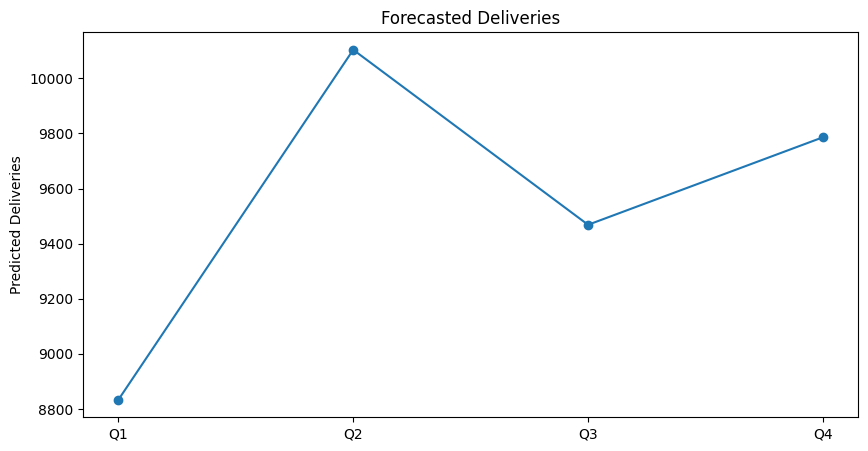

In [80]:
plt.figure(figsize=(10,5))

plt.plot(
    forecast_df['Forecast_Period'],
    forecast_df['Predicted_Deliveries'],
    marker='o'
)

plt.title(
    'Forecasted Deliveries'
)

plt.ylabel(
    'Predicted Deliveries'
)

plt.show()

### Forecasting Insight

The forecasting model predicts future Tesla deliveries by leveraging historical delivery patterns through lag features and rolling statistics. The projected values suggest the expected delivery trajectory over the next four quarters based on historical trends and operational indicators.

# Conclusion

- Tesla deliveries have generally increased over time.
- Production and deliveries are strongly correlated.
- Charging infrastructure appears positively related to deliveries.
- Feature engineering using lag features and rolling statistics improved predictive capability.
- Linear Regression performed the best on the test set, while Ridge and Lasso performed slightly worse.
- Forecasts indicate continued demand growth in future quarters.

# Business Recommendations

1. Continue expanding charging infrastructure in high-growth regions.

2. Focus production on the highest-demand vehicle models.

3. Monitor battery technology improvements to increase driving range.

4. Use forecasting models for production planning and inventory management.